# Psychological analysis: latent parameters × trial-level feelings

Refactored for clarity and robustness. This notebook:
- Loads subject-level model parameters and trial-level self-report ('feelings')
- Constructs a trial-level analysis table by merging subject-level parameters down into trials
- Runs a small set of targeted regressions testing preregisterable hypotheses
- Produces summary plots.


In [1]:
# --- Setup ---
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from scipy.stats import linregress, spearmanr
import re
# Reproducibility for any resampling (if added later)
np.random.seed(0)


## Data loading
**Expectation:**
- `model_df` is **subject-level** (one row per subject) with parameters like `z_mean`, `beta_mean`, `k_mean` and factor scores `F1..F3`.
- `feelings` is **trial-level** with columns like `subject`, `questionType`, `response`, `threat`, `distance`, `trialCookie_weight`.

**Robustness:** the loader below accepts either local absolute paths or relative paths.

In [21]:
# --- Configure data paths ---
# If you're running locally, set these to your file locations.
# If you're running in another environment, place the csvs next to this notebook and use relative paths.

MODEL_CSV = Path("/Users/nokada/Documents/CALTECH/LIMA_Analysis/Data/MODEL_PARAMS/modeling_factor_param.csv")
FEELINGS_CSV = Path("/Users/nokada/Documents/CALTECH/LIMA_Analysis/Data/ProcessingPipelineData_FINAL/stage5_filtered_data_20260102_104909/feelings.csv")
BEHAVIOR_RICH_CSV = Path("/Users/nokada/Documents/CALTECH/LIMA_Analysis/Data/ProcessingPipelineData_FINAL/stage2_trial_processing_20260109_182654/behavior_rich.csv")  

def _read_csv_safely(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}.\n"
            "Update MODEL_CSV / FEELINGS_CSV / BEHAVIOR_RICH_CSV to point to your files."
        )
    return pd.read_csv(path)

model_df = _read_csv_safely(MODEL_CSV)
feelings = _read_csv_safely(FEELINGS_CSV)

# Optional
behavior_rich = _read_csv_safely(BEHAVIOR_RICH_CSV) if BEHAVIOR_RICH_CSV.exists() else None

print("Loaded:")
print("  model_df:", model_df.shape)
print("  feelings:", feelings.shape)
print("  behavior_rich:", None if behavior_rich is None else behavior_rich.shape)


Loaded:
  model_df: (291, 9)
  feelings: (10546, 16)
  behavior_rich: (23733, 34)


## Helper utilities
These helpers remove repeated boilerplate: renaming IDs, numeric coercion, centering, safe merges, and MixedLM fitting.


In [3]:
def standardize_subject_column(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure the subject identifier column is named 'subject'."""
    df = df.copy()
    if "subject" in df.columns:
        return df
    if "subj" in df.columns:
        return df.rename(columns={"subj": "subject"})
    raise KeyError("No subject column found (expected 'subject' or 'subj').")

def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def add_centered(df: pd.DataFrame, col: str, new_col: str = None) -> pd.DataFrame:
    """Grand-mean center a column."""
    df = df.copy()
    if new_col is None:
        new_col = f"{col}_c"
    df[new_col] = df[col] - df[col].mean()
    return df

def fit_mixedlm(formula: str, data: pd.DataFrame, group_col: str = "subject",
                reml: bool = True, method: str = "lbfgs"):
    """Fit MixedLM robustly: drop rows with missing values used by the formula and groups."""
    # Identify required columns from formula in a lightweight way
    tokens = set(re.findall(r"[A-Za-z_][A-Za-z0-9_]*", formula))
    needed = [c for c in tokens if c in data.columns]
    needed = list(dict.fromkeys([*needed, group_col]))  # keep order, ensure group_col included

    df2 = data[needed].copy().dropna()
    # Fit; pass groups as column name to avoid NA-misalignment IndexErrors
    model = smf.mixedlm(formula, data=df2, groups=group_col)
    res = model.fit(reml=reml, method=method)
    return res, df2


def survival(distance, threat, z):
    """
    Compute survival probability:
    S = exp(- threat * distance^z)
    
    Works on scalars or NumPy arrays.
    """
    return np.exp(-threat * (distance ** z))

# Standardize ids once
model_df = standardize_subject_column(model_df)
feelings = standardize_subject_column(feelings)

# A good sanity check: model_df should be 1 row per subject.
dup_counts = model_df["subject"].value_counts()
n_dups = (dup_counts > 1).sum()
print(f"Subjects with >1 row in model_df: {n_dups}")
if n_dups:
    print("Example duplicate subjects:", dup_counts[dup_counts > 1].head().to_dict())


Subjects with >1 row in model_df: 0


## Construct the trial-level analysis table
**Goal:** keep trial-level rows (from `feelings`) and attach subject-level parameters (from `model_df`).
This avoids many-to-many merges and pseudoreplication mistakes.


In [ ]:
# --- Ensure model_df is truly subject-level ---
# If model_df has repeated subjects (e.g., multiple rows due to condition-wise params),
# reduce to one row per subject using a defensible aggregation.

subject_level_cols = ["k_mean", "z_mean", "beta_mean", "F1", "F2", "F3"]
available = [c for c in subject_level_cols if c in model_df.columns]

model_subj = (
    model_df
    .groupby("subject", as_index=False)[available]
    .mean()
)

# --- Build trial-level df: merge params DOWN into trials ---
trial_cols = ["subject", "questionType", "response", "threat", "distance", "trialCookie_weight","Sex","trialNumber"]
trial_cols = [c for c in trial_cols if c in feelings.columns]

df_trials = feelings[trial_cols].merge(model_subj, on="subject", how="left")

# Coerce numeric where needed
df_trials = coerce_numeric(df_trials, ["response", "threat", "distance", "trialCookie_weight",
                                       "k_mean", "z_mean", "beta_mean", "F1", "F2", "F3","Sex","trialNumber"])


df_trials["survival"] = survival(df_trials["distance"], df_trials["threat"], df_trials["z_mean"])



print("df_trials:", df_trials.shape)
df_trials.head()


# Regression 1: Do subjective feelings track inferred survival?

> Model 1: $y_{\text{response}} \sim \beta_1 \cdot \text{survival\_c} + \beta_2 \cdot \text{question}$
>
> 
>  Model 2: response ~ survival_c * z_c * question

In [10]:
# Map questionType codes (edit if your dataset differs)
QUESTION_MAP = {5: "Anxiety", 6: "Confidence"}

df1 = df_trials.copy()
df1 = df1[df1["questionType"].isin(QUESTION_MAP.keys())].copy()

In [12]:
# If survival is not present at trial-level, skip gracefully.
if "survival" not in df1.columns:
    print("Column 'survival' not found in df_trials; skipping Regression 1.")
else:
    df1 = coerce_numeric(df1, ["survival", "z_mean"])
    df1["question"] = df1["questionType"].map(QUESTION_MAP)

    df1 = add_centered(df1, "survival", "survival_c")
    df1 = add_centered(df1, "z_mean", "z_c")

    # Treat question as categorical
    df1["question"] = df1["question"].astype("category")

    res1, df1_fit = fit_mixedlm("response ~ survival_c * question", df1)
    print(res1.summary())

    res2, df1_fit = fit_mixedlm("response ~ survival_c * z_c * question", df1)
    print(res2.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       response   
No. Observations:         10498         Method:                   REML       
No. Groups:               293           Scale:                    4.0820     
Min. group size:          12            Log-Likelihood:           -22582.0641
Max. group size:          36            Converged:                Yes        
Mean group size:          35.8                                               
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          4.398    0.058  75.778 0.000  4.285  4.512
question[T.Confidence]            -1.231    0.039 -31.219 0.000 -1.308 -1.154
survival_c                        -1.836    0.107 -17.193 0.000 -2.045 -1.627
surviv

>Subjective anxiety and confidence ratings tracked model-inferred survival probability at the trial level. Lower inferred survival was associated with increased anxiety and decreased confidence, with a strong survival × question interaction indicating opposite directional effects for the two constructs. This relationship remained robust after accounting for individual differences in latent threat sensitivity (z), which showed only a weak main effect and did not significantly moderate the survival–feeling relationship.


Although latent threat sensitivity (z) strongly shapes how distance and threat are transformed into survival probability, it did not independently modulate subjective ratings once survival was accounted for. This is expected given the model architecture: z operates upstream on the inference of survival, whereas anxiety and confidence are keyed to survival itself.

In [15]:
df1["survival_bin"] = pd.qcut(
    df1["survival"],
    q=10,
    duplicates="drop"
)

df1["survival_bin_mid"] = df1["survival_bin"].apply(lambda x: x.mid)

summary = (
    df1
    .groupby(["questionType", "survival_bin_mid"])
    .agg(
        mean_response=("response", "mean"),
        n=("response", "count"),
        sem=("response", lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)

# 95% CI
summary["ci95"] = 1.96 * summary["sem"]

summary["question"] = summary["questionType"].map({
    5: "Anxiety",
    6: "Confidence"
})

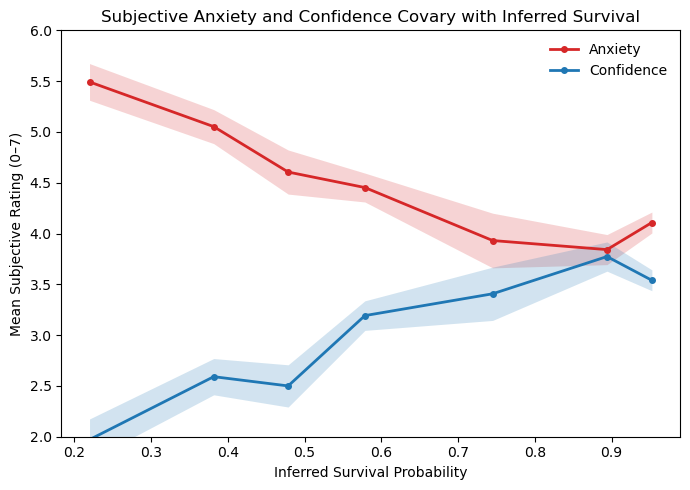

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for q, color in zip(["Anxiety", "Confidence"], ["tab:red", "tab:blue"]):
    sub = summary[summary["question"] == q].sort_values("survival_bin_mid")

    plt.plot(
        sub["survival_bin_mid"],
        sub["mean_response"],
        label=q,
        color=color,
        marker="o",
        markersize=4,
        linewidth=2
    )

    plt.fill_between(
        sub["survival_bin_mid"],
        sub["mean_response"] - sub["ci95"],
        sub["mean_response"] + sub["ci95"],
        color=color,
        alpha=0.2,
        linewidth=0
    )

plt.xlabel("Inferred Survival Probability")
plt.ylabel("Mean Subjective Rating (0–7)")
plt.title("Subjective Anxiety and Confidence Covary with Inferred Survival")
plt.ylim(2, 6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# Regression 2: Distance effect slope (near vs far) vs z
**Hypothesis (Anxiety):** subjects with higher effort–hazard mapping (`z_mean`) show a *different* change in anxiety from near→far distances (a more negative or more positive **distance slope**), potentially reflecting how threat imminence is transformed into subjective affect.

**Approach:**
1. For each subject and threat level, compute mean anxiety at the nearest and farthest distance.
2. Compute Δ(Anxiety) = far − near.
3. Test association of Δ(Anxiety) with `z_mean` (Spearman + simple OLS).


Near distance: 0 | Far distance: 2
Threat 0.1: ρ=0.081, p=0.171, n=291
Threat 0.5: ρ=0.064, p=0.273, n=291
Threat 0.9: ρ=0.145, p=0.0132, n=291
                            OLS Regression Results                            
Dep. Variable:          delta_anxiety   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.661
Date:                Fri, 09 Jan 2026   Prob (F-statistic):             0.0261
Time:                        18:13:49   Log-Likelihood:                -1698.1
No. Observations:                 873   AIC:                             3402.
Df Residuals:                     870   BIC:                             3416.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025

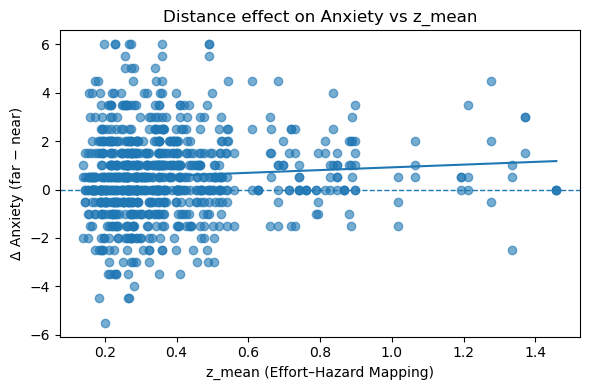

In [20]:
df2 = df_trials.copy()
df2 = df2[df2["questionType"] == 5].copy()  # Anxiety only

# Drop rows missing essentials
df2 = df2.dropna(subset=["subject", "response", "distance", "threat", "z_mean"])

# Identify nearest/farthest distances present in the data
near_d = df2["distance"].min()
far_d  = df2["distance"].max()
print("Near distance:", near_d, "| Far distance:", far_d)

near = (
    df2[df2["distance"] == near_d]
    .groupby(["subject", "threat"])["response"]
    .mean()
    .rename("near_anxiety")
)
far = (
    df2[df2["distance"] == far_d]
    .groupby(["subject", "threat"])["response"]
    .mean()
    .rename("far_anxiety")
)

delta = (far - near).rename("delta_anxiety").reset_index()

# Merge subject-level z
z_df = df2.groupby("subject", as_index=False)["z_mean"].mean()
delta = delta.merge(z_df, on="subject", how="left")

# Threat-stratified Spearman
for t in sorted(delta["threat"].dropna().unique()):
    sub = delta[delta["threat"] == t].dropna(subset=["delta_anxiety", "z_mean"])
    if len(sub) < 5:
        continue
    rho, p = spearmanr(sub["z_mean"], sub["delta_anxiety"])
    print(f"Threat {t}: ρ={rho:.3f}, p={p:.3g}, n={len(sub)}")

# Pooled OLS (with threat as a covariate)
delta = add_centered(delta, "z_mean", "z_c")
res_ols = smf.ols("delta_anxiety ~ z_c + threat", data=delta.dropna()).fit()
print(res_ols.summary())

# Quick visualization
plt.figure(figsize=(6,4))
plt.scatter(delta["z_mean"], delta["delta_anxiety"], alpha=0.6)
m, b = np.polyfit(delta["z_mean"].dropna(), delta["delta_anxiety"].dropna(), 1)
x = np.linspace(delta["z_mean"].min(), delta["z_mean"].max(), 100)
plt.plot(x, m*x + b)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("z_mean (Effort–Hazard Mapping)")
plt.ylabel("Δ Anxiety (far − near)")
plt.title("Distance effect on Anxiety vs z_mean")
plt.tight_layout()
plt.show()


## Regression 3: Trial-level Anxiety ~ threat × beta + distance + cookie
**Hypothesis:** trial-by-trial anxiety increases with threat, and this threat sensitivity is modulated by the subject's threat-bias parameter (`beta_mean`).
Distance and cookie weight are included as covariates.

**Model:** `response ~ threat_c * beta_c + distance_c + trialCookie_weight` with a random intercept per subject.


In [7]:
df_anx = df_trials.copy()
df_anx = df_anx[df_anx["questionType"] == 5].copy()  # Anxiety

# Center predictors
df_anx = df_anx.dropna(subset=["response", "threat", "beta_mean", "distance", "trialCookie_weight", "subject"])
df_anx = add_centered(df_anx, "threat", "threat_c")
df_anx = add_centered(df_anx, "beta_mean", "beta_c")
df_anx = add_centered(df_anx, "distance", "distance_c")

res_anx, df_anx_fit = fit_mixedlm(
    "response ~ threat_c * beta_c + distance_c + trialCookie_weight",
    df_anx
)
print(res_anx.summary())


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  response   
No. Observations:  5238     Method:              REML       
No. Groups:        291      Scale:               2.9360     
Min. group size:   18       Log-Likelihood:      -10605.6380
Max. group size:   18       Converged:           Yes        
Mean group size:   18.0                                     
------------------------------------------------------------
                   Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          3.654    0.090 40.542 0.000  3.477  3.831
threat_c           1.745    0.072 24.078 0.000  1.603  1.887
beta_c             0.053    0.040  1.314 0.189 -0.026  0.132
threat_c:beta_c    0.082    0.038  2.135 0.033  0.007  0.156
distance_c         0.282    0.029  9.738 0.000  0.226  0.339
trialCookie_weight 0.372    0.024 15.708 0.000  0.325  0.418
subject Var        1.548    0.085   

## Regression 4: Trial-level Confidence ~ threat × beta + distance + cookie
**Hypothesis:** trial-by-trial confidence decreases with threat, and this threat sensitivity is modulated by `beta_mean` (threat-bias).
Distance and cookie weight are included as covariates.


In [8]:
df_conf = df_trials.copy()
df_conf = df_conf[df_conf["questionType"] == 6].copy()  # Confidence

df_conf = df_conf.dropna(subset=["response", "threat", "beta_mean", "distance", "trialCookie_weight", "subject"])
df_conf = add_centered(df_conf, "threat", "threat_c")
df_conf = add_centered(df_conf, "beta_mean", "beta_c")
df_conf = add_centered(df_conf, "distance", "distance_c")

res_conf, df_conf_fit = fit_mixedlm(
    "response ~ threat_c * beta_c + distance_c + trialCookie_weight",
    df_conf
)
print(res_conf.summary())


            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  response   
No. Observations:    5236     Method:              REML       
No. Groups:          291      Scale:               3.0103     
Min. group size:     17       Log-Likelihood:      -10672.0331
Max. group size:     18       Converged:           Yes        
Mean group size:     18.0                                     
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           3.864    0.092  41.800 0.000  3.683  4.045
threat_c           -1.757    0.073 -23.927 0.000 -1.900 -1.613
beta_c             -0.033    0.042  -0.792 0.428 -0.115  0.049
threat_c:beta_c    -0.062    0.039  -1.614 0.107 -0.138  0.013
distance_c         -0.360    0.029 -12.242 0.000 -0.417 -0.302
trialCookie_weight -0.347    0.024 -14.480 0.000 -0.394 -0.300
subje

## Compact coefficient plot: Anxiety vs Confidence (key terms)
This plot summarizes the fixed-effect coefficients (and 95% CIs) from the Anxiety and Confidence MixedLM regressions.


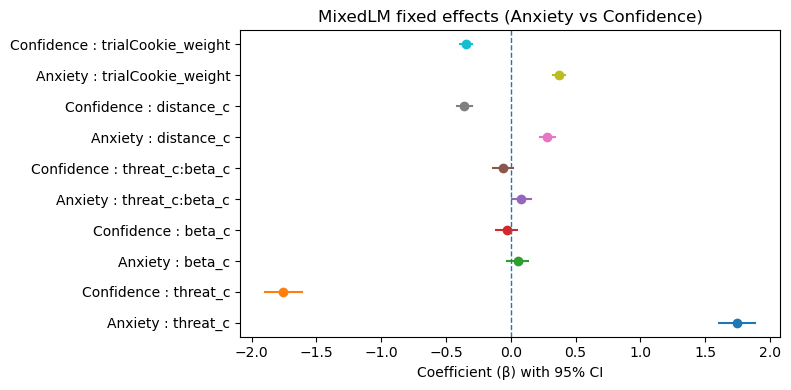

In [9]:
def coef_table(res, label):
    ci = res.conf_int()
    out = pd.DataFrame({
        "term": res.params.index,
        "beta": res.params.values,
        "ci_low": ci[0].values,
        "ci_high": ci[1].values,
    })
    out["outcome"] = label
    return out

plot_df = pd.concat([
    coef_table(res_anx, "Anxiety"),
    coef_table(res_conf, "Confidence")
], ignore_index=True)

# Keep key fixed effects (exclude intercept if you prefer)
keep_terms = ["threat_c", "beta_c", "threat_c:beta_c", "distance_c", "trialCookie_weight"]
plot_df = plot_df[plot_df["term"].isin(keep_terms)].copy()

# Order terms
term_order = keep_terms
plot_df["term"] = pd.Categorical(plot_df["term"], categories=term_order, ordered=True)
plot_df = plot_df.sort_values(["term", "outcome"])

# Plot
plt.figure(figsize=(8,4))
y_labels = []
y_pos = []
i = 0
for term in term_order:
    sub = plot_df[plot_df["term"] == term]
    for _, r in sub.iterrows():
        y_labels.append(f"{r['outcome']} : {term}")
        y_pos.append(i)
        plt.plot([r["ci_low"], r["ci_high"]], [i, i])
        plt.scatter([r["beta"]], [i])
        i += 1

plt.axvline(0, linestyle="--", linewidth=1)
plt.yticks(y_pos, y_labels)
plt.xlabel("Coefficient (β) with 95% CI")
plt.title("MixedLM fixed effects (Anxiety vs Confidence)")
plt.tight_layout()
plt.show()
